In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functions
from FNO_vmapped import *
import pybamm
import flax
import functools
import optax

In [2]:
anode_file = "trained_models/anode_GRF__2025-03-31_00-38-52.msgpack"
cathode_file = "trained_models/cathode_GRF__2025-03-31_01-26-36.msgpack"

train_data = np.load("data/spm/for_soc/test/GRF_2200.npz")
test_data = np.load("data/spm/for_soc/test/GRF_2200.npz")

In [3]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn_anode = jnp.array(train_data["target_concentration_anode"])
test_cn_anode = jnp.array(test_data["target_concentration_anode"])

train_c0_anode = jnp.array(train_data["initial_concentration_anode"])
test_c0_anode = jnp.array(test_data["initial_concentration_anode"])

train_cn_cathode = jnp.array(train_data["target_concentration_cathode"])
test_cn_cathode = jnp.array(test_data["target_concentration_cathode"])

train_c0_cathode = jnp.array(train_data["initial_concentration_cathode"])
test_c0_cathode = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [4]:
params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

In [5]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 6
hidden_channels = 64
output_channels = 1

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar

# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)

# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
#input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
anode = model.apply(params, input_tensor)
cathode = model.apply(params, input_tensor)
print("Output shape:", anode.shape)  # should be (1,24,85,1)
print("Output shape:", cathode.shape)

Output shape: (24, 85, 1)
Output shape: (24, 85, 1)


In [6]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

parameter_name = "Chen2020"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 900
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [7]:
params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [8]:
def U_OCP_an(sto):
    u_eq = (
        1.9793 * jnp.exp(-39.3631 * sto)
        + 0.2482
        - 0.0909 * jnp.tanh(29.8538 * (sto - 0.1234))
        - 0.04478 * jnp.tanh(14.9159 * (sto - 0.2769))
        - 0.0205 * jnp.tanh(30.4444 * (sto - 0.6103))
    )

    return u_eq

def U_OCP_ca(sto):
    u_eq = (
        -0.8090 * sto
        + 4.4875
        - 0.0428 * jnp.tanh(18.5138 * (sto - 0.5542))
        - 17.7326 * jnp.tanh(15.7890 * (sto - 0.3117))
        + 17.5842 * jnp.tanh(15.9308 * (sto - 0.3120))
    )

    return u_eq

In [9]:
# U_OCP_an = params_bat["Negative electrode OCP [V]"]
# U_OCP_ca = params_bat["Positive electrode OCP [V]"]
R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

In [10]:
def in_arcsinh(I, R, epsilon, L, A):

    x = I * R / (3 * epsilon * L * A)

    return x

In [11]:

t_lin = t/t_max
R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))

In [12]:
def preprocess_candidates(I_array, c0_array):
    """
    Convert a single (or batch of) current and c0 arrays into
    padded 2D channels for the FNO: shape (B, 24, 85, 4).
    
    Parameters
    ----------
    I_array : jnp.ndarray
        If shape is (75,) => a single sample. Or (B,75) => batch.
    c0_array : jnp.ndarray
        If shape is (20,) => a single sample. Or (B,20) => batch.
    
    Returns
    -------
    X : jnp.ndarray
        FNO input, shape (B, 24, 85, 4).
        Where channels are: [I_2D, c0_2D, R_padded, T_padded].
    """
    # # 1) Ensure we have a batch dimension. If user passes shape (75,), add batch=1
    # if I_array.ndim == 1:
    #     I_array = I_array[None, :]   # shape (1,75)
    # if c0_array.ndim == 1:
    #     c0_array = c0_array[None, :] # shape (1,20)
    
    # B = I_array.shape[0]  # batch size
    
    # 2) Pad along t-axis => shape (B, 75+10) = (B,85)
    I_padded = jnp.pad(I_array, (padding_t, padding_t))  # (B,85)
    # 3) Pad along r-axis => shape (B, 20+4) = (B,24)
    c0_padded = jnp.pad(c0_array, (padding_r, padding_r)) # (B,24)

    # 4) Broadcast to (B, 24,85)
    I_2D = jnp.tile(I_padded[None, :], (H, 1))       # shape (B,24,85)
    c0_2D = jnp.tile(c0_padded[:, None], (1, W))     # shape (B,24,85)
    
    # 5) Broadcast R_padded, T_padded => shape (B,24,85)
    #    They are constant, so just replicate along batch dimension
    
    # R_3D = jnp.tile(R[None, ...], (B, 1, 1))  # (B,24,85)
    # T_3D = jnp.tile(T[None, ...], (B, 1, 1))  # (B,24,85)

    # 6) Stack channels => shape (B, 24,85,4)
    X = jnp.stack([I_2D, c0_2D, R, T], axis=-1)
    
    # print(X.shape)

    return X

In [13]:
def postprocess_candidates(c_pred: jnp.ndarray,) -> jnp.ndarray:
    eps = 1e-6
    """
    Post-process FNO output for a single electrode (anode or cathode).
    1. Removes radial/time padding (2 in r, 5 in t).
    2. Extracts the last radial index (surface).
    
    Parameters
    ----------
    c_pred : jnp.ndarray
        FNO predictions of shape (B, 24, 85, 1) for a batch size B (or B=1).

    Returns
    -------
    jnp.ndarray
        Surface concentration at the outer radial index, shape (B, W_orig).
    """
    
    # Unpad the radial and time dimensions: shape (B, 20, 75)
    c_unpadded = c_pred[
        padding_r : padding_r + H_orig,
        padding_t : padding_t + W_orig,
        0
    ]

    # Take the last radial index => surface concentration, shape (B, 75)
    c_surface = c_unpadded[-1, :]


    #These values can be negative. Because they are going to be part in a square root we filter out negative values in order to avoid nans
    # c_surface = jnp.maximum(c_surface, eps)
    c_surface = jnp.clip(c_surface,eps,1-eps)

    return c_surface


In [14]:
@jax.jit
def fno_predict_voltage(c0_anode, c0_cathode, current):
# def post_proc(params, I_c, c_pred_an, c_true_an, c_pred_ca, c_true_ca, Ran, Rca, epsan, epsca, Lan, Lca, A):

    X_anode = preprocess_candidates(current,c0_anode)
    X_cathode = preprocess_candidates(current,c0_cathode)

    cn_anode = model.apply(params_anode,X_anode)
    cn_cathode = model.apply(params_cathode,X_cathode)
    
    cn_anode_surf = postprocess_candidates(cn_anode)
    cn_cathode_surf = postprocess_candidates(cn_cathode)

    j_anode = cn_anode_surf**0.5 * (1-cn_anode_surf)**0.5
    j_cathode = cn_cathode_surf**0.5 * (1-cn_cathode_surf)**0.5

    xan = in_arcsinh(-current, Ran, epsan, Lan, A)
    xca = in_arcsinh(-current, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))

    return V_pred

batch_fno_predict_voltage=jax.vmap(fno_predict_voltage, in_axes = (0,0,0), out_axes = (0))
# Warm-up the JAX-compiled function on a small subset (to exclude JIT compilation time)
_ = batch_fno_predict_voltage(test_c0_anode[:10], test_c0_cathode[:10], test_I[:10])

In [15]:
import time

In [16]:
batch_size = 1000

In [17]:
start_fno = time.perf_counter()

V_pred = batch_fno_predict_voltage(test_c0_anode[:1000], test_c0_cathode[:1000], test_I[:1000])
fno_time = time.perf_counter() - start_fno
print(f"FNO prediction for 1000 samples took: {fno_time:.4f} seconds")

# If desired, convert to numpy for later error analysis.
V_pred_np = np.array(V_pred)

FNO prediction for 1000 samples took: 3.6889 seconds


In [18]:
# start_fno = time.perf_counter()
# for i in range(17):
#     V_pred = batch_fno_predict_voltage(test_c0_anode[i*batch_size:(i+1)*batch_size-1], test_c0_cathode[i*batch_size:(i+1)*batch_size-1], test_I[i*batch_size:(i+1)*batch_size-1])
#     #print((i+1)*batch_size -1)
# fno_time = time.perf_counter() - start_fno
# print(f"FNO prediction for 8800 samples took: {fno_time:.4f} seconds")

# # If desired, convert to numpy for later error analysis.
# V_pred_np = np.array(V_pred)

In [19]:
# import time
# import numpy as np
# import pybamm

# # Ensure your time vector and number of samples are set up
# t = np.linspace(0, 900, 75)  # 75 time points from 0 to 900 seconds
# num_samples = 200 #test_I.shape[0]  # Should be 8800

# # Optionally, if you have a global parameter dictionary, copy it for each simulation.
# # Otherwise, define params_local as needed.
# # For instance:
# # params_global = { ... }  
# # and later: params_local = params_global.copy()
# spm = pybamm.lithium_ion.SPM()
# # Disable events (we only care about speed)
# spm.events = []
# soc = 0.5

# # Start the benchmark for PyBaMM simulations.
# start_pybamm = time.perf_counter()

# # Loop over each test sample
# for i in range(num_samples):
#     # Extract the current profile for this simulation (75 points)
#     I_func = test_I[i]
    
#     # Set the current function using PyBaMM's Interpolant.
#     # Note: the -1 multiplication is applied as in your block.
#     params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.0 * I_func, pybamm.t)
    
#     # Create a simulation instance with your SPM model and the updated parameters.
#     sim = pybamm.Simulation(spm, parameter_values=params_bat)
    
#     # Solve the simulation with the given initial SOC and t_eval set to t.
#     sol = sim.solve(initial_soc=soc, t_eval=t)

# # Record the total elapsed time.
# pybamm_time = time.perf_counter() - start_pybamm
# print(f"PyBaMM simulation for {num_samples} samples took: {pybamm_time:.4f} seconds")


In [20]:
_, V_true = functions.post_proc(params_bat, test_I[:batch_size], 0, test_cn_anode[:batch_size,-1,:], 0 , test_cn_cathode[:batch_size,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)

In [21]:
# Convert V_true to a NumPy array (if not already) for error computation
V_true_np = np.array(V_true)

# ----------------------------
# 3. Error Comparison
# ----------------------------
# Compute Mean Absolute Error (MAE) and Root Mean Square Error (RMSE)
mae = np.nanmean(np.abs(V_pred_np - V_true_np),axis=1)
rmse = np.sqrt(np.nanmean((V_pred_np - V_true_np)**2, axis=1))



/tmp/ipykernel_282689/64165108.py:8: RuntimeWarning: Mean of empty slice
  mae = np.nanmean(np.abs(V_pred_np - V_true_np),axis=1)
/tmp/ipykernel_282689/64165108.py:9: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((V_pred_np - V_true_np)**2, axis=1))


In [26]:
valid_indices = ~np.isnan(mae)  # Boolean mask for rows that are not NaN
mae_valid = mae[valid_indices]

In [27]:
1-mae

array([0.9990409 , 0.99871385, 0.99840915, 0.9874284 , 0.9993029 ,
       0.9987578 , 0.9975926 ,        nan, 0.99916637, 0.9980425 ,
       0.99909866, 0.9990491 , 0.99860686, 0.9992021 , 0.9997268 ,
       0.99909735, 0.99958354, 0.99910426, 0.99923784, 0.9995425 ,
       0.9991899 , 0.9994125 , 0.9986915 , 0.99917805, 0.9969651 ,
       0.9675389 , 0.9403144 ,        nan, 0.99930984, 0.9994131 ,
       0.99883795, 0.9980586 , 0.9983272 , 0.9988331 , 0.97845143,
              nan, 0.9996174 , 0.99913025, 0.99945796, 0.99957454,
       0.9984879 , 0.9757071 ,        nan,        nan, 0.9994635 ,
       0.99908626, 0.9985189 , 0.99794745, 0.9996536 , 0.9986817 ,
       0.9978103 , 0.998888  , 0.998359  , 0.96982026, 0.9430647 ,
       0.98975426, 0.99938124, 0.99939656, 0.9987493 , 0.99769133,
       0.99905497, 0.99947304, 0.9995595 , 0.9994547 , 0.99933285,
       0.99894464, 0.99869597, 0.99962217, 0.9986275 , 0.9952492 ,
              nan,        nan, 0.9991629 , 0.99907357, 0.99768

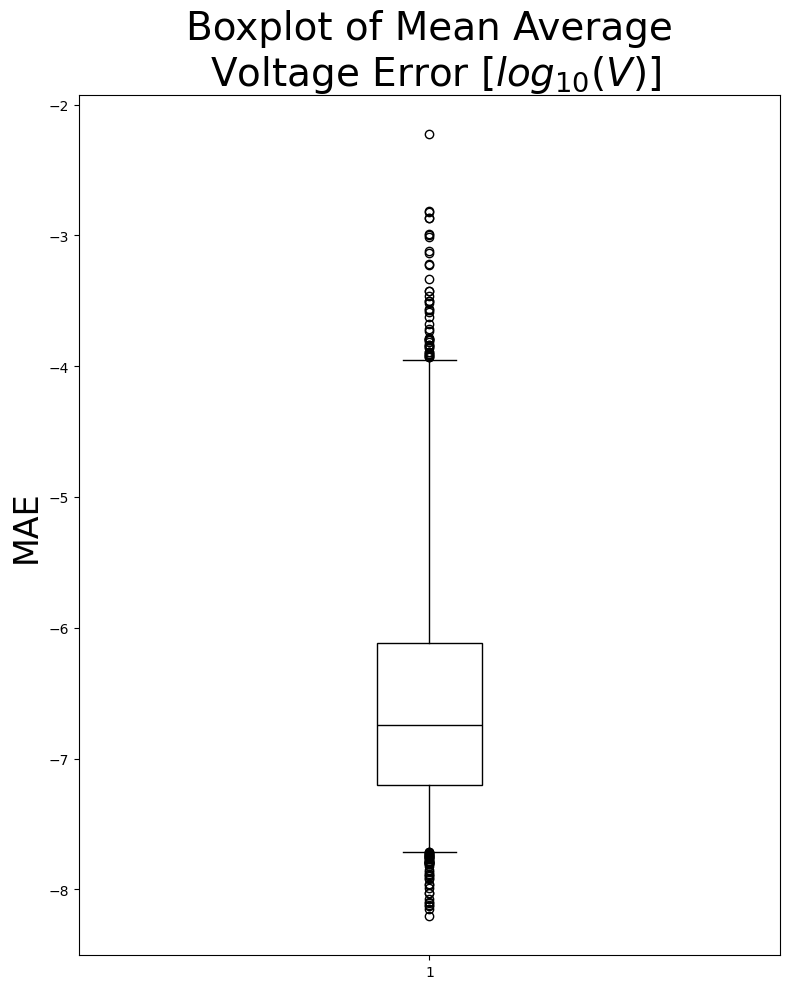

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Assume mae_valid is defined as before.

plt.figure(figsize=(8, 10))

# Plot a boxplot with the default settings.
plt.boxplot(np.log(mae_valid),
            positions=[1],
            widths=0.15,
            showfliers=True,
            whis=[5, 95],
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"))

plt.ylabel("MAE", fontsize=24)
plt.title("Boxplot of Mean Average\n Voltage Error [$log_{10}(V)$]", fontsize=28)

#plt.yscale("log")  # Set the y-axis to a logarithmic scale

plt.tight_layout()
plt.savefig("log_scale_mae_boxplot.png", dpi=300)
plt.show()


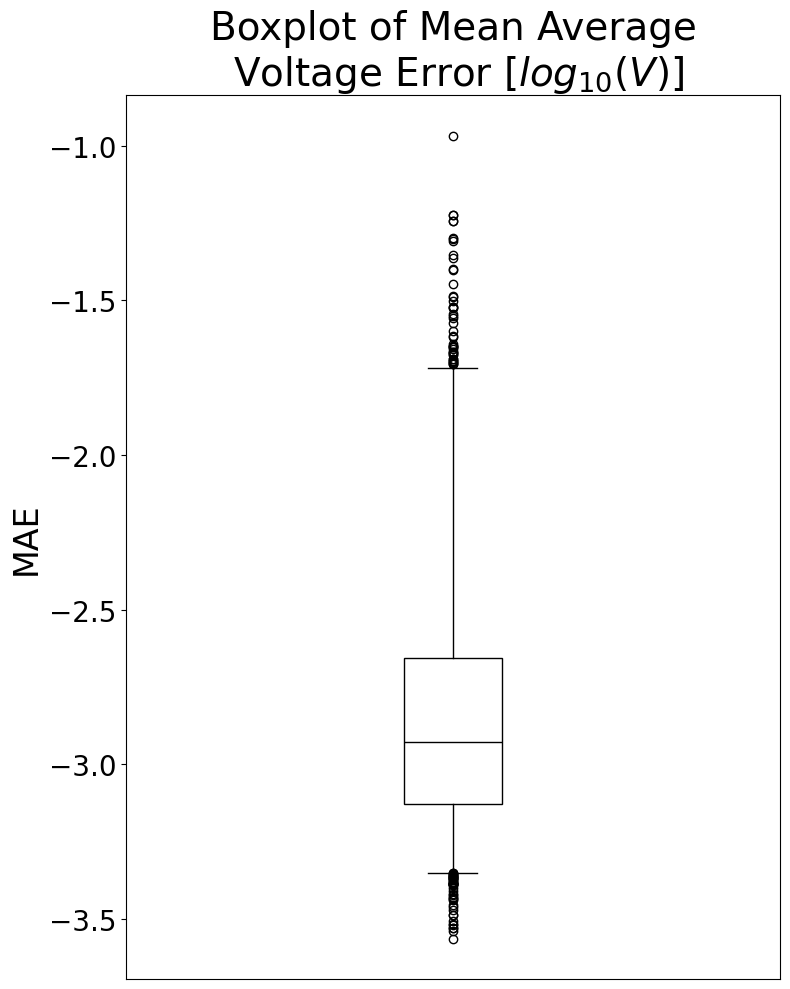

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Assume mae_valid is defined as before.
# For example:
# mae_valid = np.random.gamma(shape=2.0, scale=0.001, size=500)

plt.figure(figsize=(8, 10))

# Plot the boxplot using log10 transformation
plt.boxplot(np.log10(mae_valid),
            positions=[1],
            widths=0.15,
            showfliers=True,
            whis=[5, 95],
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"))

# Set the y-axis label and title with large fonts
plt.ylabel("MAE", fontsize=24)
plt.title("Boxplot of Mean Average\n Voltage Error [$log_{10}(V)$]", fontsize=28)

# Increase y-tick font size
plt.yticks(fontsize=20)

# Remove the x-axis tick
plt.xticks([])

plt.tight_layout()
plt.savefig("log_scale_mae_boxplot.svg", dpi=600)
plt.show()
